In [83]:
import pandas as pd 
df_tracking = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv').set_index('frame')
# print(df_tracking)
print(df_tracking.index.unique().sort_values())

# df_tracking = df_tracking.sort_values(by='frame')
# print(df_tracking)
# frame_1_df = df_tracking[df_tracking['frame'] == 1]
# print(frame_1_df)



Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            35056, 35057, 35058, 35059, 35060, 35061, 35062, 35063, 35064,
            35065],
           dtype='int64', name='frame', length=35066)


In [10]:
import pandas as pd
import dask.dataframe as dd
print("Pandas version:", pd.__version__)
print("Dask version:", dd.__version__)

Pandas version: 1.3.5


AttributeError: module 'dask.dataframe' has no attribute '__version__'

In [79]:
# def reshape_tracking_csv(df): 
#     pivoted_df = pd.DataFrame() 
#     for frame in df.index.unique():  
#        frame_data = df.loc[frame] 
#        frame_dict = dict() 
       
#        for _, obj in frame_data.iterrows(): 
#            obj_name = obj['name']
#            frame_dict[obj_name] = obj['name']
#            frame_dict[f'{obj_name}_x'] = obj['x']
#            frame_dict[f'{obj_name}_y'] = obj['y']
#            frame_dict[f'{obj_name}_w'] = obj['w']
#            frame_dict[f'{obj_name}_h'] = obj['h']
#        pivoted_df = pivoted_df.append(pd.Series(frame_dict, name=frame))
#     return pivoted_df

# reshaped_df = reshape_tracking_csv(df_tracking)
# print(reshaped_df)
#this takes too long 


KeyboardInterrupt: 

In [9]:
#Rescale the coordinates of the label csv to 1280x720 

import pandas as pd
import os 
# Read the CSV file
def change_resolution(file_path):
    df = pd.read_csv(file_path)
    scale_factor = 4/3 #scale factor from 960x540 to 1280x720
    coordinate_columns = ['xmin', 'ymin', 'xmax', 'ymax']
    df[coordinate_columns] = (df[coordinate_columns] * scale_factor).astype(int)

    df['width'] = 1280
    df['height'] = 720
    print(df)
    return df 
# Save the transformed coordinates
# for file in os.listdir(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy'):
#     df = change_resolution(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file))
#     df.to_csv(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file), index=False)
# # df.to_csv('data/ground_truth_labels/1.2.3_C1_labels.csv', index=False)

               filename  width  height         class  xmin  ymin  xmax  ymax  \
0    1.2.3_C1_00001.png   1280     720        helmet    34   360   112   421   
1    1.2.3_C1_00001.png   1280     720  spray bottle   221   310   253   360   
2    1.2.3_C1_00001.png   1280     720   paper towel   266   285   296   362   
3    1.2.3_C1_00001.png   1280     720          step   721   501   916   576   
4    1.2.3_C1_00001.png   1280     720      dumbbell   869   341   921   368   
..                  ...    ...     ...           ...   ...   ...   ...   ...   
553  1.2.3_C1_00059.png   1280     720   granola bar   469   344   498   365   
554  1.2.3_C1_00059.png   1280     720    flower pot   160   333   213   392   
555  1.2.3_C1_00059.png   1280     720      dumbbell   888   341   938   362   
556  1.2.3_C1_00059.png   1280     720      dumbbell   936   341   992   365   
557  1.2.3_C1_00059.png   1280     720     jump rope   514   344   568   366   

     index  
0        5  
1        5  


In [1]:
import pandas as pd 
import pickle as pkl 

with open(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\resources\gen_sim_glove_50.pkl', 'rb') as f: 
    glove_vectors = pkl.load(f)
tracking_csv_1 = r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv'
tracking_df_1 = pd.read_csv(tracking_csv_1)
print(tracking_df_1)

        frame          name           x           y          w          h  \
0         194   flower pot0   40.234783  362.109711  48.933249  52.833668   
1         195   flower pot0   52.622172  364.008237  47.976467  52.259548   
2         196   flower pot0   57.526331  363.574705  47.186493  51.706933   
3         197   flower pot0   59.975720  364.299649  46.405327  51.415962   
4         198   flower pot0    3.429873  326.859361  45.682774  49.578674   
...       ...           ...         ...         ...        ...        ...   
376124  35061  granola bar5  468.341740  344.925943  31.697070  19.450150   
376125  35062  granola bar5  468.780556  344.806872  31.276563  19.629429   
376126  35063  granola bar5  469.275008  344.631029  30.738902  19.910859   
376127  35064  granola bar5  469.321917  344.673047  29.872956  20.297805   
376128  35065  granola bar5  469.000000  344.000000  29.000000  21.000000   

        confidence  ground_truth  width  height  
0         0.345971       

In [73]:
tracking_df_1 = tracking_df_1.sort_values(by='frame')
tracking_df_1_frame_1 = tracking_df_1[tracking_df_1['frame'] == 0].copy() #will have to iterate over every frame 
#need to put .copy() since i am modifying the copy and not the view 

emb_dim = glove_vectors['apple'].size
# tracking_df_1_frame_1.loc[:,'name'] = tracking_df_1_frame_1.loc[:, 'name'].apply(lambda x: "".join([char for char in x if not char.isdigit()]))
# print(tracking_df_1_frame_1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import dask.dataframe as dd 

sample_eye = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\all_eye_080422.csv").compute()
print(sample_eye)

         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1633729  35119  3.1.3.mp4    NaN    NaN  e159100
1633730  35119  3.1.3.mp4    NaN    NaN  e159100
1633731  35119  3.1.3.mp4    NaN    NaN  e159100
1633732  35119  3.1.3.mp4    NaN    NaN  e159100
1633733  35119  3.1.3.mp4  236.0  404.8  e159100

[169559578 rows x 5 columns]


In [3]:
movie_data = sample_eye[sample_eye['video'] == '1.2.3.mp4']

In [9]:
frame_1 = movie_data[movie_data['frame']==1]
print(frame_1.groupby(['sub']).mean())

         frame           x           y
sub                                   
e159001    1.0  637.388235  360.494118
e159002    1.0  634.947059  342.082353
e159004    1.0  637.358824  372.541176
e159005    1.0  639.523529  373.252941
e159013    1.0  646.570588  370.888235
...        ...         ...         ...
e159096    1.0  620.415385  352.084615
e159097    1.0  635.600000  363.065217
e159098    1.0  647.677273  369.618182
e159099    1.0  640.360714  349.942857
e159100    1.0  640.194118  369.829412

[79 rows x 3 columns]


In [4]:
sample_eye_movie_1 = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\1.2.3_eye_080422.csv").compute()
print(sample_eye_movie_1)
unique_list = sample_eye_movie_1['frame'].unique().tolist()


         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1779087  35129  1.2.3.mp4    NaN    NaN  e159100
1779088  35129  1.2.3.mp4    NaN    NaN  e159100
1779089  35129  1.2.3.mp4    NaN    NaN  e159100
1779090  35129  1.2.3.mp4    NaN    NaN  e159100
1779091  35129  1.2.3.mp4  757.7 -629.3  e159100

[39244395 rows x 5 columns]


In [66]:
def GaussianMask(sizex, sizey, sigma=10, center=None, fix=1):
    """
    Generate a Gaussian mask.
    sizex  : mask width
    sizey  : mask height
    sigma  : Gaussian standard deviation
    center : Gaussian mean (center of the mask)
    fix    : Maximum value of the Gaussian function
    return : Gaussian mask as a 2D numpy array
    """
    x = np.arange(0, sizex, 1, float)
    # print(x)
    y = np.arange(0, sizey, 1, float)
    x, y = np.meshgrid(x, y) #creates a grid of x and y values 
    # print(y.shape)
    # print(y)
    if center is None:
        x0 = sizex // 2
        y0 = sizey // 2
    else:
        if not np.isnan(center[0]) and not np.isnan(center[1]):
            x0 = center[0]
            y0 = center[1]
        else:
            return np.zeros((sizey, sizex))
    gaussian_mask = fix * np.exp(-((x - x0) ** 2 / sigma ** 2 + (y - y0) ** 2 / sigma ** 2)) #2D gaussian filter 
    # print(gaussian_mask.shape)
    # print(gaussian_mask)
    return gaussian_mask


def Fixpos2Densemap(fix_arr, width, height):
    """
    Convert fixation positions to a density map.
    fix_arr : array of fixation data [number of subjects x 3(x,y,fixation)]
    width   : output image width
    height  : output image height
    return  : heatmap as a 2D numpy array
    """
    heatmap = np.zeros((height, width), np.float32)
    for n_subject in range(fix_arr.shape[0]):
        center = (fix_arr[n_subject][1], fix_arr[n_subject][2])
        place = GaussianMask(width, height, sigma=33, center=center)
        # print("Sum: ", np.sum(place))
        heatmap += place
    heatmap /= fix_arr.shape[0] 
    normalized_heatmap = heatmap / heatmap.sum()
 
    return (normalized_heatmap)*1000 #scale values by 1000 





In [74]:
frame_1 = sample_eye_movie_1[sample_eye_movie_1['frame'] == 50] 
avg_frame = frame_1.groupby(['sub']).mean()
values = avg_frame.to_numpy()
print(values)

width, height = 1280, 720

# Generate the heatmap
heatmap = Fixpos2Densemap(values, width, height)
print(heatmap)
print("overall heatmap sum", heatmap.sum())

[[  50.          620.85882353  367.47058824]
 [  50.          642.71176471  335.13529412]
 [  50.          496.76470588  346.92352941]
 [  50.          544.64705882  378.57647059]
 [  50.          700.56470588  500.69411765]
 [  50.          496.65882353  342.06470588]
 [  50.          206.02777778  365.87777778]
 [  50.          221.57647059  408.41764706]
 [  50.          892.85555556  350.29444444]
 [  50.          940.7625      407.11875   ]
 [  50.          897.28823529  390.08235294]
 [  50.          494.07647059  314.23529412]
 [  50.          278.95294118  347.51176471]
 [  50.          526.61176471  370.16470588]
 [  50.          921.08823529  389.49411765]
 [  50.          383.98125     525.85625   ]
 [  50.          906.41176471  338.34705882]
 [  50.          815.29411765  460.87058824]
 [  50.          861.48888889  341.77777778]
 [  50.          891.70625     328.45625   ]
 [  50.          416.025       526.1       ]
 [  50.          712.90588235  352.13529412]
 [  50.   

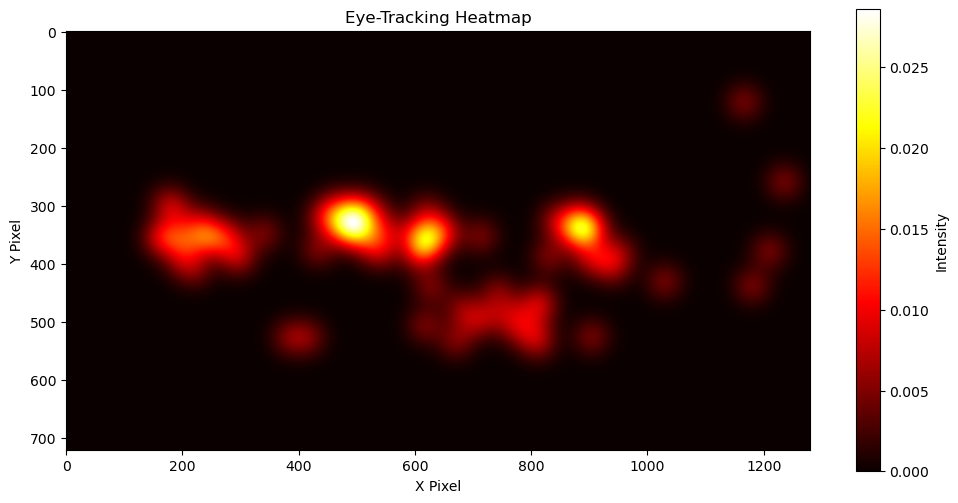

In [68]:
plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap')
plt.colorbar(label='Intensity')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

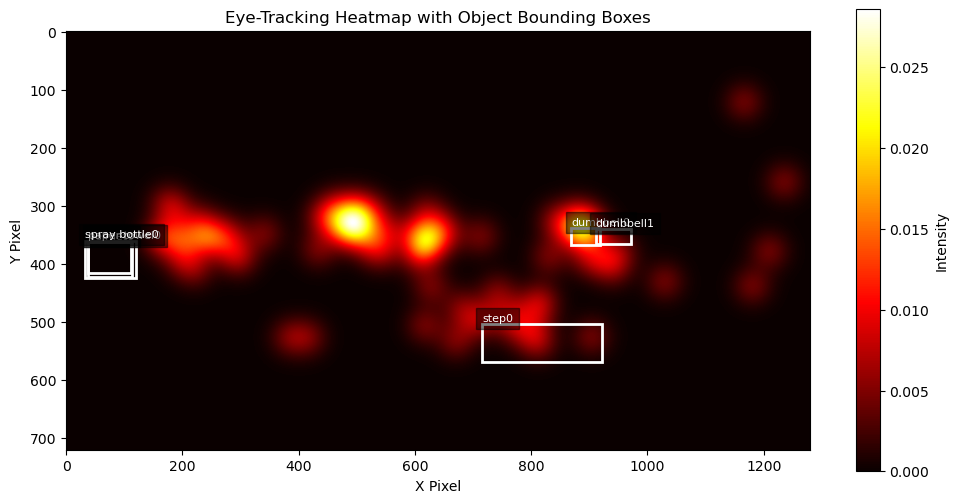

In [75]:
plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap with Object Bounding Boxes')
plt.colorbar(label='Intensity')


for _, obj in tracking_df_1_frame_1.iterrows():
    rect = plt.Rectangle((obj['x'], obj['y']), 
                        obj['w'],  # width
                        obj['h'],  # height
                        fill=False, edgecolor='white', linewidth=2)
    plt.gca().add_patch(rect)
    # Add object labels
    plt.text(obj['x'], obj['y']-5, obj['name'], 
             color='white', fontsize=8, 
             bbox=dict(facecolor='black', alpha=0.5))

plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


In [84]:
def attention_weight(heatmap, tracking_df):
    attention_weights = dict()
    epsilon = 1e-6 #make sure the average is not 0 
    boxes = tracking_df_1_frame_1[['name', 'x', 'y', 'w', 'h']].values
    attention_weights = {
            row[0]: np.mean(heatmap[int(row[2]):int(row[2])+int(row[4]), 
                                      int(row[1]):int(row[1])+int(row[3])]) + epsilon
            for row in boxes
        }
    total = sum(attention_weights.values())
    attention_weights = {k: v / total for k, v in attention_weights.items()}
    print(sum(attention_weights.values()))
    print(attention_weights.values())
    return attention_weights

attention_weights = attention_weight(heatmap, tracking_df_1_frame_1)


0.9999999999999999
dict_values([0.6322877419631798, 0.0010293827921859764, 0.1252752982371653, 0.0010249014228499648, 0.0018765179947389948, 0.23850615758987978])


In [72]:
print(glove_vectors['dumbbell']*attention_weights['dumbbell'])
print(glove_vectors['helmet']*attention_weights['helmet'])

[-0.05903106  0.14623825 -0.22462419 -0.37355423  0.20585307  0.28885722
  1.0603019   0.21002372  0.12188251  0.09847376 -0.32544595  0.21647751
  0.53096825  0.7259374  -0.46827894 -0.29228193 -0.28308445  0.41812754
  0.09674842 -0.35494527  0.1864528  -0.6052873  -0.07708221 -0.05893182
 -0.21764503 -0.00966446  0.15922366  0.74247736 -0.06896795 -0.69772243
 -0.18751654  0.51828116 -0.1515894   0.83419245  0.02842455  0.40047204
  0.3556004  -0.01086766  0.12867358 -0.18491557  0.22630411  0.06494649
 -0.41091484  0.3293701  -0.5804127  -0.22240591  0.657443    0.26921695
  0.07258726 -0.13171561]
[-3.8786030e-03  5.3046300e-05 -1.5998432e-04 -9.7806298e-04
  4.5927364e-04  1.5061746e-03 -1.8708556e-04 -2.2040990e-03
  3.8172957e-04 -2.6468001e-03  2.3152642e-03  2.0570452e-03
 -1.4973284e-03  1.5564802e-03 -5.3505407e-04  1.0510440e-03
 -2.0492070e-03  9.3957095e-04 -3.0785273e-03 -3.2240977e-03
 -3.3332752e-03 -2.9189602e-04 -2.7855115e-03 -2.8671708e-03
 -4.3127939e-04 -4.20081

In [61]:
import numpy as np

def get_emb(df, emb_dim, attention_weights): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r * attention_weights[row['name']] #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim, attention_weights))


[[-0.00717957 -0.00123235 -0.00113726 -0.00372283  0.00134811  0.00310391
  -0.00236065 -0.00584413  0.00154673 -0.00271167  0.00275536  0.0026059
   0.00106814  0.00231253  0.00117961  0.00280022 -0.00503169  0.00224204
  -0.00608655 -0.0120505  -0.00079187 -0.00030655  0.00033322 -0.00667036
  -0.0032921  -0.0103577  -0.00300852  0.01160225  0.00919104 -0.00559227
   0.01265684  0.00068051 -0.00600791  0.00533267 -0.00344365  0.00789964
   0.00503508  0.00273505  0.00516394 -0.00126069  0.00761167  0.00257372
  -0.00119837  0.00508455  0.0037407  -0.0006494   0.00123553 -0.00295795
   0.00364618 -0.00678178]]


In [47]:
import numpy as np

def get_emb(df, emb_dim): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim))

[[-0.28382416 -0.0045955  -0.20979783 -0.41331116  0.22721866  0.31037251
   0.45230023 -0.15986167  0.14456342 -0.01298666 -0.06806434  0.255996
   0.18631916  0.55724866 -0.154315    0.08497733 -0.30999834  0.24254417
  -0.15224741 -0.92987334  0.11762732 -0.32735543 -0.076015   -0.43871116
  -0.24445084 -0.82040501 -0.02167391  0.99822464  0.4997175  -0.63639485
   1.10353168  0.38416257 -0.64318584  0.65770668 -0.18776149  0.53953666
   0.46823016  0.20148334  0.28551749 -0.21889548  0.42600917  0.1398975
  -0.35257084  0.36289566 -0.05950033 -0.13435155  0.44144749  0.05992251
   0.24445767 -0.39373166]]


In [6]:
import numpy as np
obj_handling_emb = np.full(shape=(1, 100), fill_value=np.nan)
print(obj_handling_emb)
obj_handling_embs = np.zeros(shape=(0, 100))
print(obj_handling_embs)

obj_handling_embs = np.vstack([obj_handling_embs, obj_handling_emb])
print(obj_handling_embs)



[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]
[]
[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]


In [13]:
import pandas as pd
import numpy as np
import dask.dataframe as dd 
from pandas import DataFrame
# from src.utils import parse_config
import os 

def GaussianMask(sizex, sizey, sigma=10, center=None, fix=1):
    """
    Generate a Gaussian mask.
    sizex  : mask width
    sizey  : mask height
    sigma  : Gaussian standard deviation
    center : Gaussian mean (center of the mask)
    fix    : Maximum value of the Gaussian function
    return : Gaussian mask as a 2D numpy array
    """
    x = np.arange(0, sizex, 1, float)
    y = np.arange(0, sizey, 1, float)
    x, y = np.meshgrid(x, y)
    if center is None:
        x0 = sizex // 2
        y0 = sizey // 2
    else:
        if not np.isnan(center[0]) and not np.isnan(center[1]):
            x0 = center[0]
            y0 = center[1]
        else:
            return np.zeros((sizey, sizex))
    return fix * np.exp(-((x - x0) ** 2 / sigma ** 2 + (y - y0) ** 2 / sigma ** 2))

def Fixpos2Densemap(fix_arr, width, height):
    """
    Convert fixation positions to a density map.
    fix_arr : array of fixation data [number of subjects x 3(x,y,fixation)]
    width   : output image width
    height  : output image height
    return  : heatmap as a 2D numpy array
    """
    heatmap = np.zeros((height, width), np.float32)
    for n_subject in range(fix_arr.shape[0]):
        center = (fix_arr[n_subject, 1], fix_arr[n_subject, 2])
        place = GaussianMask(width, height, 33, center=center)
        heatmap += place
    heatmap /= fix_arr.shape[0]
    normalized_heatmap = heatmap / np.sum(heatmap) #normalize the heatmap to sum to 1 
    return normalized_heatmap*1000 #scale values by 1000 


def generate_heatmaps_and_attention_weights(frame, movie_data, width, height, tracking_df): 
    current_frame = movie_data[movie_data['frame'] == frame]
    new_frame = current_frame.groupby(['sub']).mean()
    values = new_frame.to_numpy() 
    heatmap = Fixpos2Densemap(values, width, height)

    def attention_weights(heatmap, tracking_df, frame):
        current_frame = tracking_df[tracking_df['frame'] == frame]
        attention_weights = {}
        epsilon = 1e-6 #make sure the average is not 0 

        boxes = current_frame[['name', 'x', 'y', 'w', 'h']].values
        attention_weights = {
            row[0]: np.mean(heatmap[int(row[2]):int(row[2])+int(row[4]), 
                                   int(row[1]):int(row[1])+int(row[3])]) + epsilon
            for row in boxes
        }
        
        total = sum(attention_weights.values())
        attention_weights = {k: v / total for k, v in attention_weights.items()} #normalize the attention weights
       
        print(attention_weights.values())
        return attention_weights
    attention_weights = attention_weights(heatmap, tracking_df, frame)
    return heatmap, attention_weights


if __name__ == "__main__":  
    # args = parse_config()
    tracking_df = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv')
    eye_data = dd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\all_eye_080422.csv').compute() 
    output_dir = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output"  # adjust path as needed

    if not os.path.exists(os.path.join(output_dir, "attention_weights")):
        os.makedirs(os.path.join(output_dir, "attention_weights"), exist_ok=True)
    if not os.path.exists(os.path.join(output_dir, "heatmaps")):
        os.makedirs(os.path.join(output_dir, "heatmaps"), exist_ok=True)

    #save the attention weights and heatmaps as csv and npy files 
    attention_weights_path = os.path.join(output_dir, "attention_weights", "1.2.3_C1_attention_weights.csv")
    heatmaps_path = os.path.join(output_dir, "heatmaps", "1.2.3_C1_heatmaps.npy")  # adjust path as needed
    movie_data = eye_data[eye_data['video'] == '1.2.3.mp4']
    # unique_frames = tracking_df.index.unique().sort_values() 
    unique_frames = range(1,10)

    heatmaps = dict()
    attention_weights_dict = dict()
    for f in unique_frames: 
        heatmap, attention_weights = generate_heatmaps_and_attention_weights(f, movie_data, 1280, 720, tracking_df)
        heatmaps[f] = heatmap 
        attention_weights_dict[f] = attention_weights

    attention_df = pd.DataFrame.from_dict(attention_weights_dict, orient='index')
    attention_df.to_csv(attention_weights_path)

    np.save(heatmaps_path, heatmaps)



<built-in method values of dict object at 0x0000016413F1D868>
<built-in method values of dict object at 0x0000016413F35C78>
<built-in method values of dict object at 0x0000016413F21278>
<built-in method values of dict object at 0x0000016413F21548>
<built-in method values of dict object at 0x0000016414722A48>
<built-in method values of dict object at 0x0000016413F35BD8>
<built-in method values of dict object at 0x0000016414722278>
<built-in method values of dict object at 0x0000016414722BD8>
<built-in method values of dict object at 0x0000016414722958>


In [25]:
data = np.load(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_heatmaps.npy", allow_pickle=True)
data_items = data.item()
print(data_items.keys())
print(data_items[1])


dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9])
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


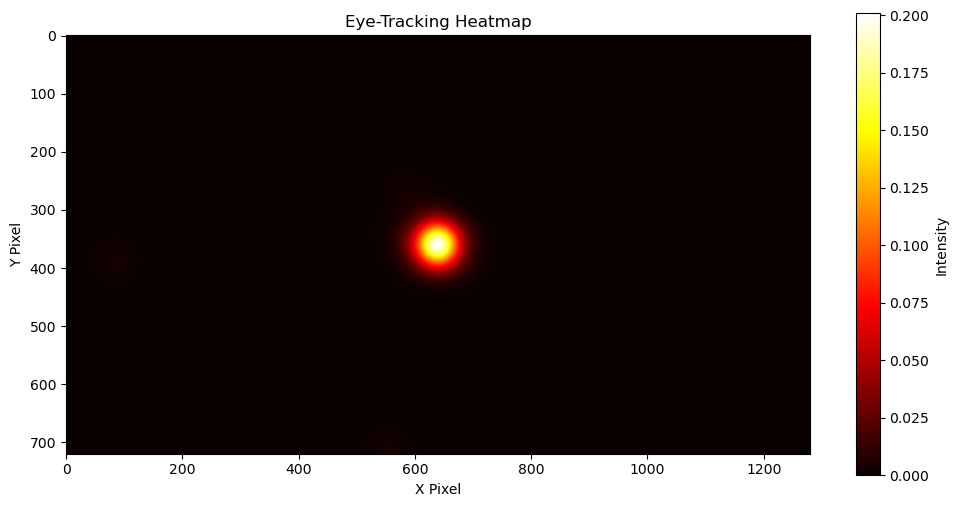

In [26]:
plt.figure(figsize=(12, 6))
plt.imshow(data_items[1], cmap='hot')
plt.title('Eye-Tracking Heatmap')
plt.colorbar(label='Intensity')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()